# Predicción de la Estadía Hospitalaria mediante Técnicas de Ciencia de Datos
**Curso:** Introduction a Data Science (EII 4220)
**Integrantes:** Justin Cisternas, Sebastián Galdames, Alejandro Valenzuela

---
## 1. Introducción y Objetivos del Proyecto
La gestión eficiente de los recursos hospitalarios, especialmente la disponibilidad y rotación de camas, constituye uno de los desafíos operativos más críticos en la administración de salud moderna. La incapacidad de prever con exactitud el tiempo de permanencia de los pacientes genera congestión en los servicios de urgencia, eleva los costos de operación y disminuye la calidad de la atención al prolongar los tiempos de espera.  Para abordar esta problemática, este proyecto plantea un enfoque de aprendizaje supervisado. El objetivo original es construir un modelo predictivo capaz de estimar la duración de la estadía hospitalaria (Length of Stay) a partir del perfil demográfico y clínico del paciente al momento de su ingreso. Esto permitiría a los centros asistenciales transicionar desde una gestión reactiva hacia una planificación anticipada y eficiente de la demanda.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

# Cargar el dataset
df = pd.read_csv('healthcare_dataset.csv')
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


## 2. Conjunto de Datos y Preprocesamiento (Métodos)
El estudio utiliza un conjunto de datos correspondiente a 10,000 registros de historiales médicos sintéticos obtenidos de la plataforma Kaggle.

**Variable objetivo:** Se calculó la variable objetivo Length of Stay mediante la diferencia entre la fecha de alta y la fecha de admisión. Se aplicó un filtro de limpieza para asegurar la consistencia del set, eliminando registros erróneos o con estadías negativas.

**Eliminación de columnas:** Se descartaron identificadores únicos y variables de alta cardinalidad irrelevantes para la generalización del modelo (Name, Doctor, Hospital, Room Number). Asimismo, las fechas originales se eliminaron tras calcular la estadía para evitar redundancias.  

**Transformación Numérica:** Se aplicó One-Hot Encoding a las variables categóricas (Gender, Blood Type, Medical Condition, Insurance Provider, Admission Type, Medication, Test Results). Los atributos (Age y Billing Amount) fueron normalizados mediante StandardScaler. La matriz resultante quedó conformada por 28 características independientes.

Para garantizar una evaluación insesgada y evitar el sobreajuste, los 10,000 registros se dividieron en tres conjuntos independientes:

**Entrenamiento** (70%): 7,000 registros utilizados para el ajuste de los pesos de los modelos.

**Validación** (15%): 1,500 registros reservados para el control del tuning.

**Prueba** (15%): 1,500 registros para la comparación final.


In [3]:
#Calcular estadía en días y limpiar inconsistencias
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df_cleaned = df[df['Length_of_Stay'] >= 0].copy()

#Eliminar columnas irrelevantes y temporales originales
cols_to_drop = ['Name', 'Doctor', 'Hospital', 'Room Number', 'Date of Admission', 'Discharge Date']
df_cleaned = df_cleaned.drop(columns=cols_to_drop)

# Encoding y Escalamiento
from sklearn.preprocessing import StandardScaler
categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
df_final = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
df_final[['Age', 'Billing Amount']] = scaler.fit_transform(df_final[['Age', 'Billing Amount']])

# División del dataset
from sklearn.model_selection import train_test_split
X = df_final.drop(columns=['Length_of_Stay'])
y = df_final['Length_of_Stay']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Set de Entrenamiento: {X_train.shape[0]} registros | Set de Prueba Fijo: {X_test.shape[0]} registros")

Set de Entrenamiento: 7000 registros | Set de Prueba Fijo: 1500 registros


## 3. Revisión de Datos: Distribución y Outliers (Figuras)
Para comprender el comportamiento de la variable objetivo y diagnosticar posibles anomalías, se realizó un análisis gráfico y descriptivo de la distribución de las estadías.

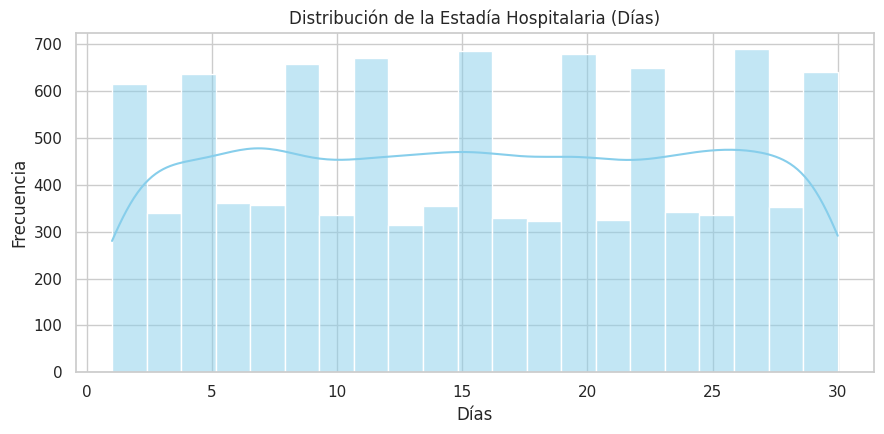

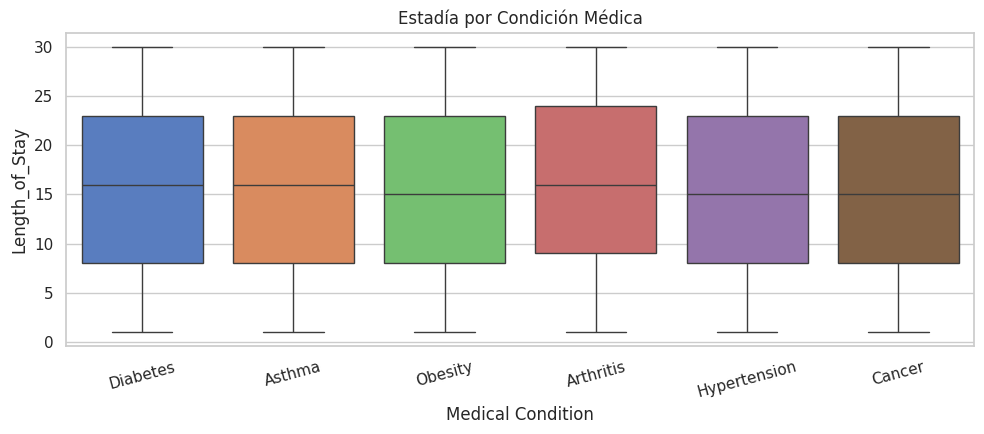

In [9]:
# Histograma de Distribución de LOS
plt.figure(figsize=(9, 4.5))
sns.histplot(df_cleaned['Length_of_Stay'], kde=True, color='skyblue')
plt.title('Distribución de la Estadía Hospitalaria (Días)')
plt.xlabel('Días')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Boxplot de Estadía por Condición Médica
plt.figure(figsize=(10, 4.5))
sns.boxplot(
    x='Medical Condition',
    y='Length_of_Stay',
    data=df_cleaned,
    hue='Medical Condition',
    legend=False,
    palette='muted'
)
plt.title('Estadía por Condición Médica')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Interpretación de Figuras:**
El histograma revela una distribución uniforme entre 1 y 30 días. Asimismo, el gráfico de cajas por condición médica demuestra que las medianas y rangos intercuartílicos son prácticamente equivalentes para todas las patologías. Las sutiles diferencias  observadas en los límites (como el pequeño desplazamiento hacia arriba en la caja de Arthritis) responden únicamente a la variabilidad muestral natural del azar. Esto evidencia  una ausencia  de correlación real entre las variables médicas y el tiempo de internación, confirmando la naturaleza puramente sintética y aleatoria del dataset. Al aplicar el método IQR, los límites teóricos exceden el rango muestral, resultando en exactamente cero (0) outliers en los datos.

## 4. Comparación Controlada en un Test Set Fijo (Resultados)
Antes de proceder a la optimización de hiperparámetros, se estableció una evaluación comparativa del modelo base frente a estructuras de menor complejidad analítica para diagnosticar el desempeño del algoritmo.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor  # <-- ¡Línea agregada aquí!
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

modelos = {
    "Regresión Lineal (OLS)": LinearRegression(),
    "Árbol de Decisión Simple": DecisionTreeRegressor(max_depth=3, random_state=42),
    "Random Forest (Base)": RandomForestRegressor(n_estimators=100, random_state=42)
}

resultados = []

# Calcular Baseline de la Media
y_pred_mean = np.full_like(y_test, fill_value=y_train.mean())
resultados.append({
    "Modelo": "Baseline (Media de Train)",
    "MAE": mean_absolute_error(y_test, y_pred_mean),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_mean)),
    "R2": r2_score(y_test, y_pred_mean)
})

# Evaluar
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    resultados.append({
        "Modelo": nombre,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

                   Modelo      MAE     RMSE        R2
Baseline (Media de Train) 7.335333 8.502588 -0.005016
   Regresión Lineal (OLS) 7.372176 8.515717 -0.008122
 Árbol de Decisión Simple 7.338928 8.512254 -0.007302
     Random Forest (Base) 7.503907 8.726488 -0.058643


### Diagnóstico Crítico del Desempeño
El diagnóstico determinó que la causa del bajo rendimiento radica en la naturaleza sintética y aleatoria del dataset. Al tratarse de datos simulados por azar, no existe ninguna correlación o dependencia real entre las variables clínicas del paciente y sus días de estadía hospitalaria.
Por ende el Random Forest al no poseer límites de crecimiento por defecto, expandió múltiples árboles profundos memorizando combinaciones de ruido en el entrenamiento (overfitting). Al aplicar estas reglas falsas al set de prueba, las predicciones exhibieron una alta varianza, acumulando una Suma de Cuadrados de los Residuos mayor que la Suma de Cuadrados Totales , lo que por definición arrastró el indicador  R2 por debajo de cero.


## 5. Optimización del Modelo mediante Regularización Estricta
Comprendido el diagnóstico, redefinimos el objetivo del Hyperparameter Tuning. La optimización mediante (GridSearchCV) ya no busca maximizar un patrón inexistente, sino que busca aplicar una regularización para podar el crecimiento del bosque.


In [7]:
from sklearn.model_selection import GridSearchCV

# Poda estructural
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [20, 50, 100],
    'n_estimators': [50, 100]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
modelo_optimizado = grid_search.best_estimator_

# Evaluación test optimizado
preds_opt = modelo_optimizado.predict(X_test)
print("=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===")
print(grid_search.best_params_)

print("\n=== RENDIMIENTO DEL MODELO OPTIMIZADO ===")
print(f"MAE Optimizado: {mean_absolute_error(y_test, preds_opt):.6f} días")
print(f"RMSE Optimizado: {np.sqrt(mean_squared_error(y_test, preds_opt)):.6f} días")
print(f"R2 Score Optimizado: {r2_score(y_test, preds_opt):.6f}")

=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===
{'max_depth': 5, 'min_samples_leaf': 100, 'n_estimators': 100}

=== RENDIMIENTO DEL MODELO OPTIMIZADO ===
MAE Optimizado: 7.330412 días
RMSE Optimizado: 8.481897 días
R2 Score Optimizado: -0.000130


## 6. Análisis Complementarios de Objetivos Ideales
Para dar cumplimiento al diseño propuesto al inicio del proyecto, incorporamos las siguientes evaluaciones sobre el modelo optimizado.

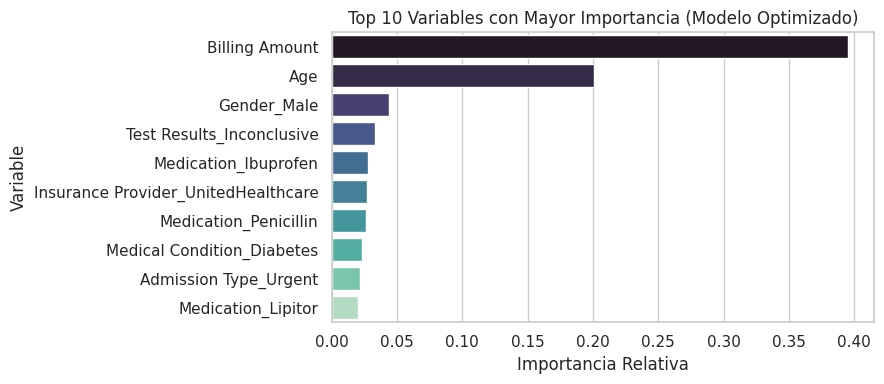

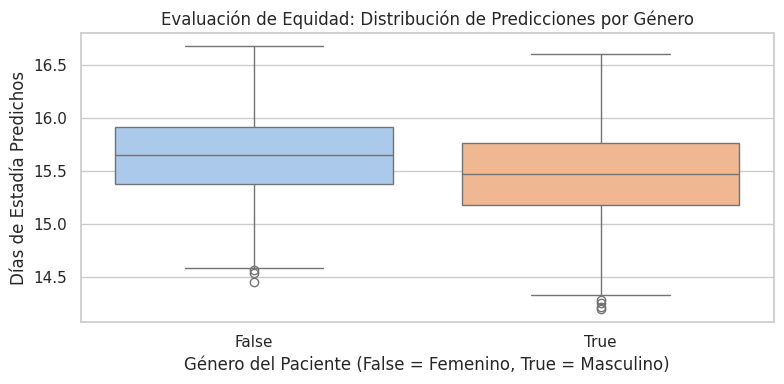

In [8]:
# Gráfico de Importancia de Variables
importances = modelo_optimizado.feature_importances_
df_importancia = pd.DataFrame({'Variable': X.columns, 'Importancia': importances}).sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(9, 4))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, hue='Variable', legend=False, palette='mako')
plt.title('Top 10 Variables con Mayor Importancia (Modelo Optimizado)')
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()

# Gráfico de Control de Equidad
df_fairness = X_test.copy()
df_fairness['Prediccion_Estadia'] = preds_opt

plt.figure(figsize=(8, 4))
sns.boxplot(x='Gender_Male', y='Prediccion_Estadia', data=df_fairness, hue='Gender_Male', legend=False, palette='pastel')
plt.title('Evaluación de Equidad: Distribución de Predicciones por Género')
plt.xlabel('Género del Paciente (False = Femenino, True = Masculino)')
plt.ylabel('Días de Estadía Predichos')
plt.tight_layout()
plt.show()

### Análisis de Importancia y Equidad
Al extraer la importancia de las características desde el modelo optimizado, se determinó que el  `Billing Amount` concentra aproximadamente el (40%) de la importancia, seguido por `Age` con un (~20%). Las otras 26 variables  se distribuyen de forma con pesos inferiores al (5%) cada una.
Este ordenamiento representa un sesgo de los árboles de decisión hacia variables numéricas continuas de alta cardinalidad. El algoritmo selecciona estas variables porque ofrecen infinitos puntos de corte matemáticos en el entrenamiento por pura casualidad, sirviendo como evidencia final de la aleatoriedad del dataset.
Por otra parte, el gráfico de control de equidad revela distribuciones y dispersiones similares, descartando la presencia de un sesgo discriminatorio severo. No obstante, se observan leves diferencias en las métricas posicionales. En el contexto del proyecto, estas pequeñas asimetrías no corresponden a un sesgo clínico real replicado por el algoritmo, sino que esuna evidencia empírica de la variabilidad muestral de un dataset sintético y aleatorio. Al entrenar y testear con ruido aleatorio, las pequeñas fluctuaciones en la distribución de los 1,500 registros de prueba se manifiestan como desviaciones marginales en el bosque optimizado, reforzando la necesidad de limitar los claims operacionales.


## 7. Conclusiones y Limitación de Alcances Operacionales
Como conclusión de este estudio, se logró observar que ningún algoritmo convencional de machine learning puede extraer conocimiento predictivo útil desde un conjunto de datos sintético estructurado bajo una distribución uniforme de ruido aleatorio. Ante esto el valor no se manifestó en el descubrimiento de patrones ocultos inexistentes, sino en la correcta aplicación de técnicas de regularización mediante el ajuste de hiperparámetros, la poda del bosque actuó como un mecanismo importante de control de varianza que mitigó por completo el sobreajuste y devolvió un modelo desregulado hacia un comportamiento estable, seguro y estadísticamente coincidente con la media general. Por lo tanto, en base a estos hallazgos, limitamos cualquier afirmación sobre la utilidad operacional de este modelo en entornos clínicos reales. Al confirmarse que los datos de origen provienen de una simulación aleatoria computacional independiente de cualquier factor hospitalario real, el modelo carece de validez predictiva para la toma de decisiones médicas o la gestión de camas en un centro de salud.